# Libraries imported

In [ ]:
from __future__ import annotations
import argparse
import sys
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif


# DATA CLEANING

In [ ]:

# ---------------------------------------------------------------------------
# CONFIG — edit these in Colab if your paths differ
# ---------------------------------------------------------------------------

DEFAULT_INPUT = Path("all_data.csv")
DEFAULT_OUTPUT = Path("clean_data_basic.csv")

# None = do not cap RT (matches original notebook behaviour).
# 99.5 = clip the top 0.5% of RT values to that percentile (reduces crazy outliers).
RT_WINSORIZE_PERCENTILE: Optional[float] = 99.5

# Columns we carry through analysis (same list as basic_cleaning.ipynb; missing names skipped)
KEEP_COLS = [
    "paper",
    "subj_ident",
    "trial_idx",
    "ss_value",
    "ss_time",
    "ll_value",
    "ll_time",
    "choice",
    "rt",
    "subj_excl",
    "trial_excl",
    "age",
    "country",
    "procedure",
    "incentivization",
    "online_study",
    "presentation_of_information",
    "fixed_attributes",
    "time_pressure",
    "currency",
]


def _log(msg: str) -> None:
    print(msg, flush=True)


def exclusion_mask_is_true(series: pd.Series) -> pd.Series:
    """
    Return True where the row is *marked excluded* (should be removed).

    Handles real booleans, 0/1, and common string spellings so the team gets the same
    result even if the CSV mixes types a little.
    """
    s = series
    if s.dtype == bool:
        return s.fillna(False)

    # Numeric 0/1
    if pd.api.types.is_numeric_dtype(s):
        num = pd.to_numeric(s, errors="coerce").fillna(0)
        return num != 0

    # Strings like 'True', 'true', '1'
    t = s.astype(str).str.strip().str.lower()
    return t.isin(["true", "1", "yes", "t"])


def run_cleaning(input_path: Path, output_path: Path, rt_winsorize: Optional[float]) -> Path:
    if not input_path.is_file():
        sys.exit(f"Input file not found: {input_path.resolve()}")

    _log(f"Reading: {input_path}")
    # Peek header first so we only load columns we need (faster + fewer mixed-type surprises)
    header = pd.read_csv(input_path, nrows=0, low_memory=False).columns.tolist()
    usecols = [c for c in KEEP_COLS if c in header]
    missing = [c for c in KEEP_COLS if c not in header]
    if missing:
        _log(f"  (Columns not in file, skipped: {missing})")

    df = pd.read_csv(input_path, usecols=usecols, low_memory=False, engine="c")
    _log(f"  Loaded shape: {df.shape}")

    n0 = len(df)

    # --- Core identifiers: trim stray spaces on text IDs (cheap data hygiene) ---
    if "subj_ident" in df.columns:
        df["subj_ident"] = df["subj_ident"].astype(str).str.strip()
    if "paper" in df.columns:
        df["paper"] = df["paper"].astype(str).str.strip()

    # --- Choice: must be a clean 0/1 label ---
    if "choice" not in df.columns:
        sys.exit("Dataset has no 'choice' column — cannot continue.")
    df["choice"] = pd.to_numeric(df["choice"], errors="coerce")
    df = df[df["choice"].isin([0, 1])].copy()
    _log(f"  After choice in {{0,1}}: {len(df):,} rows (dropped {n0 - len(df):,})")
    n0 = len(df)

    # --- Task amounts and delays: must be usable numbers for modelling ---
    for c in ["ss_value", "ss_time", "ll_value", "ll_time"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    core = [c for c in ["ss_value", "ss_time", "ll_value", "ll_time"] if c in df.columns]
    if len(core) == 4:
        before = len(df)
        df = df.dropna(subset=core)
        _log(f"  After dropping rows missing SS/LL value or time: {len(df):,} (dropped {before - len(df):,})")

    # --- Response time: positive only (same rule as notebook) ---
    if "rt" in df.columns:
        df["rt"] = pd.to_numeric(df["rt"], errors="coerce")
        before = len(df)
        df = df[df["rt"].notna() & (df["rt"] > 0)].copy()
        _log(f"  After RT present and > 0: {len(df):,} (dropped {before - len(df):,})")

        if rt_winsorize is not None:
            cap = df["rt"].quantile(rt_winsorize / 100.0)
            n_cap = (df["rt"] > cap).sum()
            df["rt"] = df["rt"].clip(upper=cap)
            _log(
                f"  RT winsorize at p{rt_winsorize}: cap={cap:.4g}, clipped rows={n_cap:,} "
                f"(set RT_WINSORIZE_PERCENTILE = None to disable)"
            )

    # --- Exclusions ---
    if "subj_excl" in df.columns:
        before = len(df)
        bad = exclusion_mask_is_true(df["subj_excl"])
        df = df[~bad].copy()
        _log(f"  After removing subject-excluded rows: {len(df):,} (dropped {before - len(df):,})")

    if "trial_excl" in df.columns:
        before = len(df)
        bad = exclusion_mask_is_true(df["trial_excl"])
        df = df[~bad].copy()
        _log(f"  After removing trial-excluded rows: {len(df):,} (dropped {before - len(df):,})")

    # --- Helpful numeric columns used everywhere downstream ---
    if all(c in df.columns for c in ("ll_value", "ss_value")):
        df["value_diff"] = df["ll_value"] - df["ss_value"]
    if all(c in df.columns for c in ("ll_time", "ss_time")):
        df["time_diff_days"] = df["ll_time"] - df["ss_time"]

    # --- Optional: make a few context columns easier for pandas / models ---
    if "age" in df.columns:
        df["age"] = pd.to_numeric(df["age"], errors="coerce")  # keep NaN if unknown
    if "trial_idx" in df.columns:
        df["trial_idx"] = pd.to_numeric(df["trial_idx"], errors="coerce")
    if "online_study" in df.columns:
        df["online_study"] = pd.to_numeric(df["online_study"], errors="coerce")
    if "time_pressure" in df.columns:
        df["time_pressure"] = pd.to_numeric(df["time_pressure"], errors="coerce")

    # Light string cleanup for categoricals (does not drop rows)
    for c in ["country", "procedure", "incentivization", "currency", "presentation_of_information", "fixed_attributes"]:
        if c in df.columns:
            df[c] = df[c].astype(str).replace({"nan": np.nan}).replace("", np.nan)

    # Same column order as basic_cleaning.ipynb (easier to diff files across teammates)
    ordered = [c for c in KEEP_COLS if c in df.columns]
    for extra in ("value_diff", "time_diff_days"):
        if extra in df.columns and extra not in ordered:
            ordered.append(extra)
    df = df[ordered]

    df.to_csv(output_path, index=False)
    _log("")
    _log(f"Saved: {output_path.resolve()}")
    _log(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    _log("Column list:")
    _log("  " + ", ".join(df.columns.tolist()))

    # Sanity check for the fast choice model (friendly error if someone edits KEEP_COLS wrong)
    need_for_fast_model = {
        "choice",
        "subj_ident",
        "ss_value",
        "ss_time",
        "ll_value",
        "ll_time",
        "value_diff",
        "time_diff_days",
        "procedure",
        "incentivization",
        "online_study",
    }
    have = set(df.columns)
    if not need_for_fast_model <= have:
        _log("")
        _log("WARNING: output is missing columns needed by choice_model_fast.py:")
        _log("  " + ", ".join(sorted(need_for_fast_model - have)))

    return output_path


def main() -> None:
    parser = argparse.ArgumentParser(description="Build clean_data_basic.csv from all_data.csv")
    parser.add_argument("--input", type=Path, default=DEFAULT_INPUT, help="Raw CSV path")
    parser.add_argument("--output", type=Path, default=DEFAULT_OUTPUT, help="Where to save cleaned CSV")
    parser.add_argument(
        "--no-rt-cap",
        action="store_true",
        help="Disable RT winsorizing (match original notebook exactly).",
    )
    args = parser.parse_args([]) # Modified to handle Colab kernel arguments

    rt_cap = None if args.no_rt_cap else RT_WINSORIZE_PERCENTILE
    run_cleaning(args.input, args.output, rt_cap)


if __name__ == "__main__":
    main()

Reading: all_data.csv
  Loaded shape: (1172644, 20)
  After choice in {0,1}: 1,172,644 rows (dropped 0)
  After dropping rows missing SS/LL value or time: 1,172,644 (dropped 0)
  After RT present and > 0: 1,172,326 (dropped 318)
  RT winsorize at p99.5: cap=16.93, clipped rows=5,862 (set RT_WINSORIZE_PERCENTILE = None to disable)
  After removing subject-excluded rows: 1,133,132 (dropped 39,194)
  After removing trial-excluded rows: 1,026,276 (dropped 106,856)

Saved: /content/clean_data_basic.csv
Final shape: 1,026,276 rows × 22 columns
Column list:
  paper, subj_ident, trial_idx, ss_value, ss_time, ll_value, ll_time, choice, rt, subj_excl, trial_excl, age, country, procedure, incentivization, online_study, presentation_of_information, fixed_attributes, time_pressure, currency, value_diff, time_diff_days


# Data Exploration

/tmp/ipykernel_47846/712961067.py:28: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv(DEFAULT_OUTPUT)
/tmp/ipykernel_47846/712961067.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_47846/712961067.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


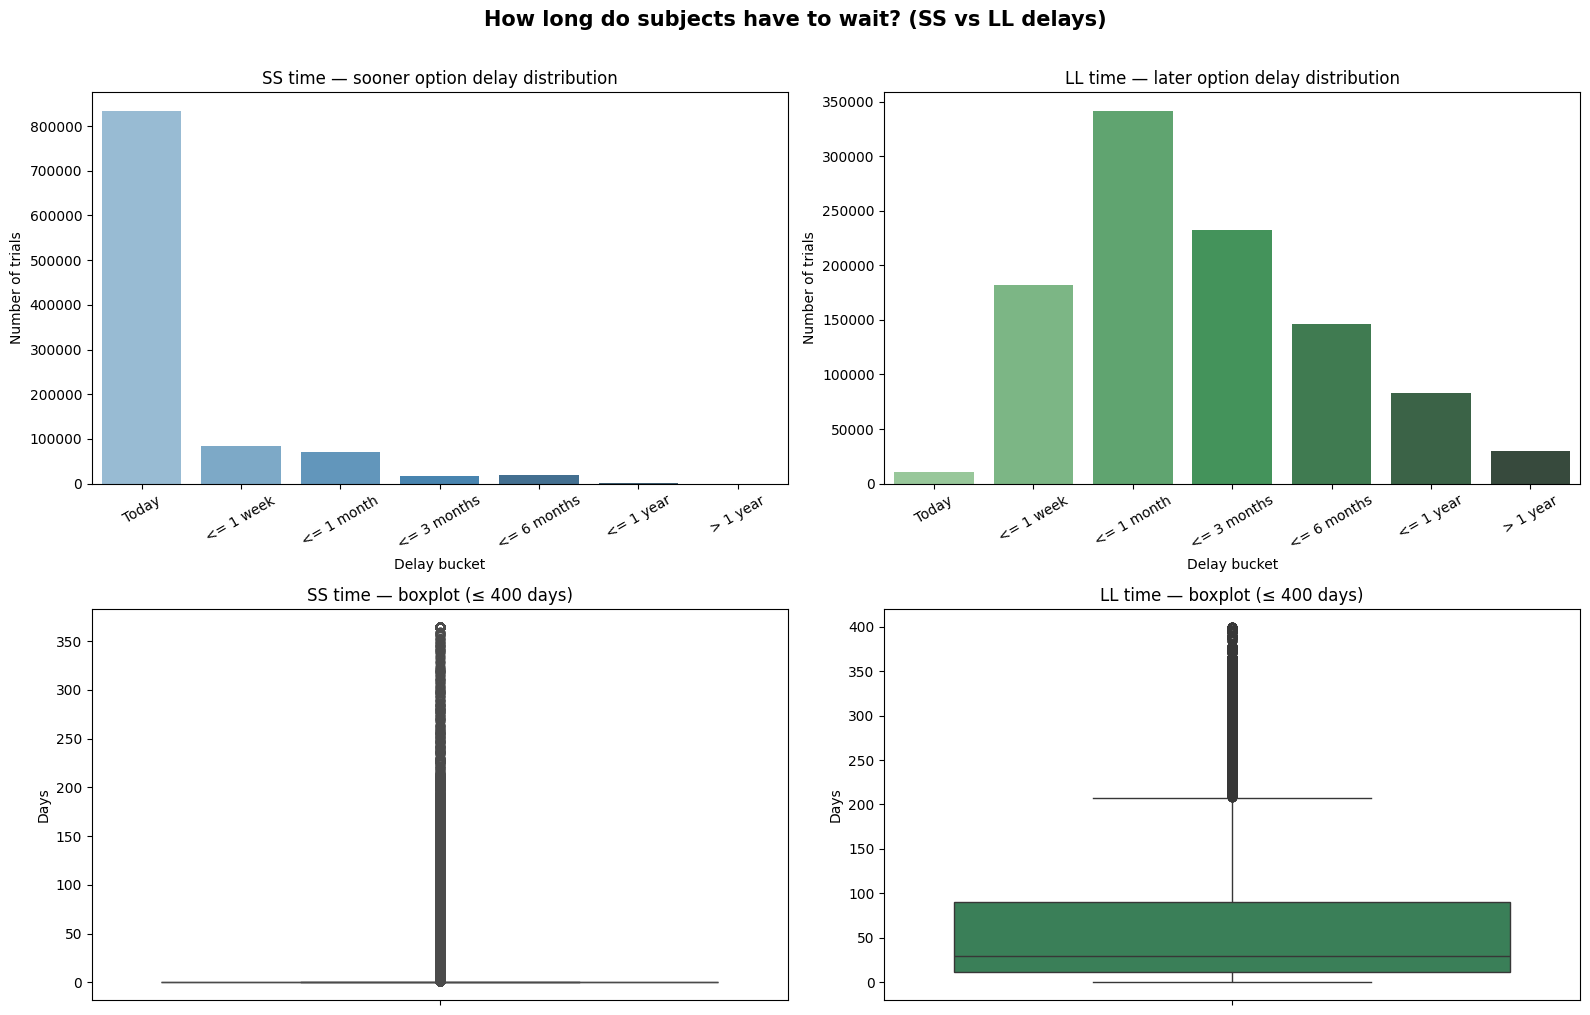

Saved: plot_01_delay_distribution.png


In [ ]:
# =============================================================================
# Viz — Delay distribution dashboard (SS vs LL)
# =============================================================================
# CONFIG

DELAY_PLOT_PATH = Path("plot_01_delay_distribution.png")
BOX_PLOT_MAX_DAYS = 400  # cap for bottom row only; keeps long tails readable
def days_to_label(days):
    """Bucket delay in days for ordered count plots (SS/LL comparable)."""
    if pd.isna(days):
        return "> 1 year"
    d = float(days)
    if d == 0:
        return "Today"
    if d <= 7:
        return "<= 1 week"
    if d <= 30:
        return "<= 1 month"
    if d <= 90:
        return "<= 3 months"
    if d <= 180:
        return "<= 6 months"
    if d <= 365:
        return "<= 1 year"
    return "> 1 year"

# Load the cleaned data
df_clean = pd.read_csv(DEFAULT_OUTPUT)

# Work on a copy so we never overwrite df_clean
plot_df = df_clean.copy()
plot_df["ss_time_label"] = plot_df["ss_time"].apply(days_to_label)
plot_df["ll_time_label"] = plot_df["ll_time"].apply(days_to_label)
ORDER = [
    "Today",
    "<= 1 week",
    "<= 1 month",
    "<= 3 months",
    "<= 6 months",
    "<= 1 year",
    "> 1 year",
]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "How long do subjects have to wait? (SS vs LL delays)",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
# Top row: how often each delay bucket appears (trial counts)
sns.countplot(
    data=plot_df,
    x="ss_time_label",
    order=ORDER,
    palette="Blues_d",
    ax=axes[0, 0],
)
axes[0, 0].set_title("SS time — sooner option delay distribution")
axes[0, 0].set_xlabel("Delay bucket")
axes[0, 0].set_ylabel("Number of trials")
axes[0, 0].tick_params(axis="x", rotation=30)
sns.countplot(
    data=plot_df,
    x="ll_time_label",
    order=ORDER,
    palette="Greens_d",
    ax=axes[0, 1],
)
axes[0, 1].set_title("LL time — later option delay distribution")
axes[0, 1].set_xlabel("Delay bucket")
axes[0, 1].set_ylabel("Number of trials")
axes[0, 1].tick_params(axis="x", rotation=30)
# Bottom row: raw days (subset for display)
ss_box = plot_df[plot_df["ss_time"] <= BOX_PLOT_MAX_DAYS]
ll_box = plot_df[plot_df["ll_time"] <= BOX_PLOT_MAX_DAYS]
sns.boxplot(data=ss_box, y="ss_time", color="steelblue", ax=axes[1, 0])
axes[1, 0].set_title(f"SS time — boxplot (≤ {BOX_PLOT_MAX_DAYS} days)")
axes[1, 0].set_ylabel("Days")
sns.boxplot(data=ll_box, y="ll_time", color="seagreen", ax=axes[1, 1])
axes[1, 1].set_title(f"LL time — boxplot (≤ {BOX_PLOT_MAX_DAYS} days)")
axes[1, 1].set_ylabel("Days")
plt.tight_layout()
plt.savefig(DELAY_PLOT_PATH, bbox_inches="tight", dpi=130)
plt.show()
print(f"Saved: {DELAY_PLOT_PATH}")

THe Goal here was to first look at how long is SS and how long is LL.

What we learned is clear: SS is mostly immediate, but not always. Around 81% is exactly 0 day, so yes often instant, but still some cases with delay (even up to 365 days). LL is typically around 30 days (about 4.3 weeks, almost 1 month), so the common trade-off is basically “now vs around one month later”.

We also saw very big outliers, especially on LL time (very huge max), so mean can be misleading. This is why we trust median more for interpretation. Then we will need to add a winsorized (capped) version to make analysis more robust, but without deleting many rows. So we keep data richness, but reduce extreme values impact.

In short: for me this Q1 gives the base story of dataset — people mostly choose between immediate option and delayed option around one month, with some extreme cases we need to control carefully.

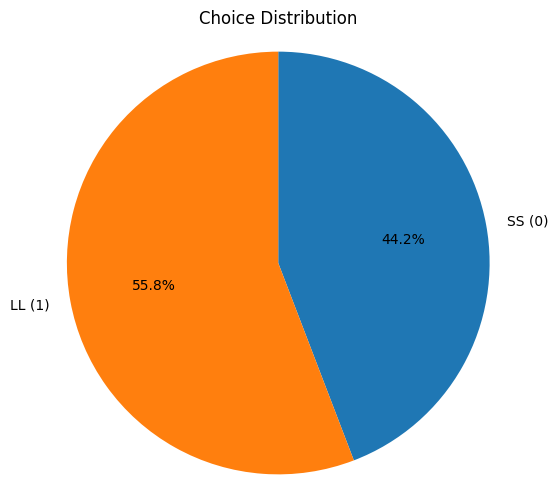

In [ ]:
choice_counts = df_clean["choice"].value_counts().sort_index()
labels = ["SS (0)", "LL (1)"] if set(choice_counts.index.tolist()) <= {0, 1} else [str(v) for v in choice_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    choice_counts.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
plt.title("Choice Distribution")
plt.axis("equal")
plt.show()

Here We take a quick look at LL and SS distribution

/tmp/ipykernel_47846/2324879291.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ratio_df, x='choice', y='reward_ratio_cap', ax=axes[1], palette=['#9ecae1', '#74c476'])


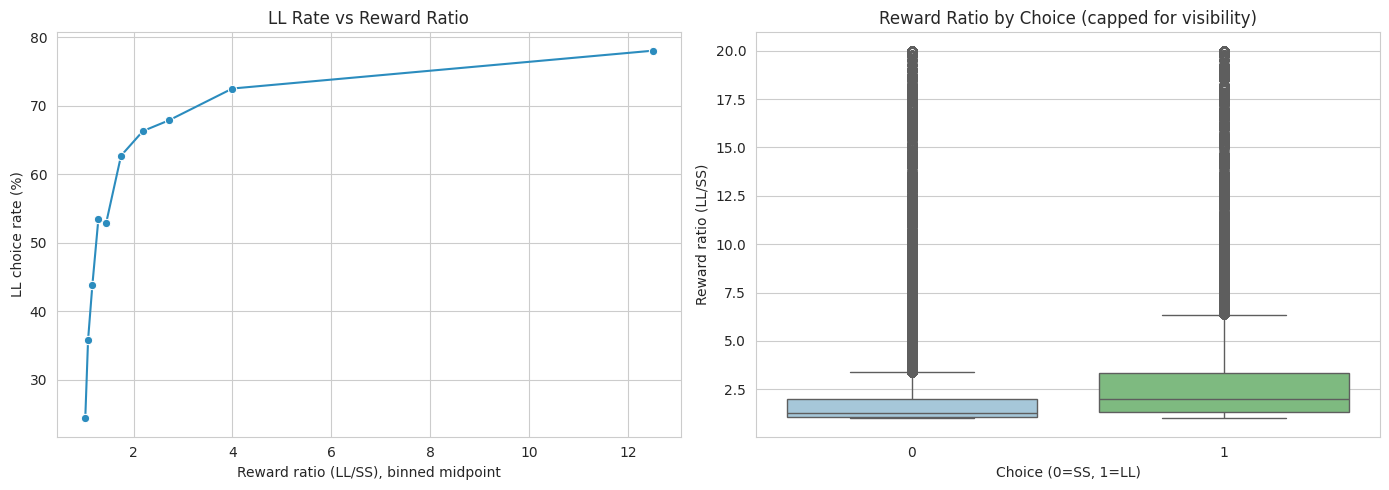

Approx tipping reward ratio (LL/SS) where LL >= 50%: 1.289
Ratio bounds for capped view: p01=1.000 p99=20.000
Overall median reward ratio: 1.538


In [ ]:
sns.set_style('whitegrid')

# Reward ratio = LL value / SS value
# Keep only valid positive denominator rows for stable ratio
ratio_df = df_clean[(df_clean['ss_value'] > 0) & (df_clean['ll_value'] > 0)].copy()
ratio_df['reward_ratio'] = ratio_df['ll_value'] / ratio_df['ss_value']

# Cap extreme ratio tails only for plotting stability (not deleting main df)
low_r = ratio_df['reward_ratio'].quantile(0.01)
high_r = ratio_df['reward_ratio'].quantile(0.99)
ratio_df['reward_ratio_cap'] = ratio_df['reward_ratio'].clip(low_r, high_r)

# Bin ratio for LL-rate curve
ratio_df['ratio_bin'] = pd.qcut(ratio_df['reward_ratio_cap'], q=10, duplicates='drop')
ll_by_bin = (
    ratio_df.groupby('ratio_bin', observed=False)['choice']
    .mean()
    .reset_index(name='ll_rate')
)
ll_by_bin['ll_rate_pct'] = ll_by_bin['ll_rate'] * 100

# Midpoint per bin for easier trend plot
ll_by_bin['bin_mid'] = ll_by_bin['ratio_bin'].apply(lambda x: (x.left + x.right) / 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: LL rate vs reward ratio bin midpoint
sns.lineplot(data=ll_by_bin, x='bin_mid', y='ll_rate_pct', marker='o', ax=axes[0], color='#2b8cbe')
axes[0].set_title('LL Rate vs Reward Ratio')
axes[0].set_xlabel('Reward ratio (LL/SS), binned midpoint')
axes[0].set_ylabel('LL choice rate (%)')

# Plot 2: Boxplot of reward ratio by final choice
sns.boxplot(data=ratio_df, x='choice', y='reward_ratio_cap', ax=axes[1], palette=['#9ecae1', '#74c476'])
axes[1].set_title('Reward Ratio by Choice (capped for visibility)')
axes[1].set_xlabel('Choice (0=SS, 1=LL)')
axes[1].set_ylabel('Reward ratio (LL/SS)')

plt.tight_layout()
plt.show()

# Approximate tipping point: first bin midpoint where LL rate >= 50%
tip_rows = ll_by_bin[ll_by_bin['ll_rate_pct'] >= 50]
if len(tip_rows) > 0:
    tipping_ratio = tip_rows.iloc[0]['bin_mid']
    print(f"Approx tipping reward ratio (LL/SS) where LL >= 50%: {tipping_ratio:.3f}")
else:
    print('LL rate does not cross 50% in these bins.')

print('Ratio bounds for capped view:', f"p01={low_r:.3f}", f"p99={high_r:.3f}")
print('Overall median reward ratio:', f"{ratio_df['reward_ratio'].median():.3f}")

For this Graph, we wanted to understand one simple business question:

how much bigger LL reward must be before people start choosing LL more than SS.

What we see here:
clear positive trend: when reward ratio increases, LL choice rate increases.
approximate tipping point is around 1.29 ratio (LL starts being chosen at least half the time).
boxplot also confirms LL choices generally happen at higher reward ratios than SS choices.


Why this matters:
this gives an interpretable threshold for decision behavior.
in business terms, users need a clear extra value to accept waiting/long-term option.
this is useful for designing upgrade offers: if value gap is too small, many users stay in short-term choice; if value gap passes threshold, LL adoption increases.

Countries included: 18
       country  ll_rate  n_trials
         Japan 0.356814      3478
        Mexico 0.393237      2070
     Australia 0.425855     15200
         Mixed 0.434261     36234
       Ireland 0.477686     14520
      Colombia 0.524528      2120
           USA 0.546631    345683
       Denmark 0.559111     19531
            UK 0.560057     37298
   Netherlands 0.569526      4955
        Israel 0.569965     10248
         China 0.571871     93063
       Germany 0.572514    295329
         Italy 0.586665     89869
   Switzerland 0.610895     22855
Czech Republic 0.612999     16124
       Belgium 0.691903     13499
          Iran 0.701667      4200


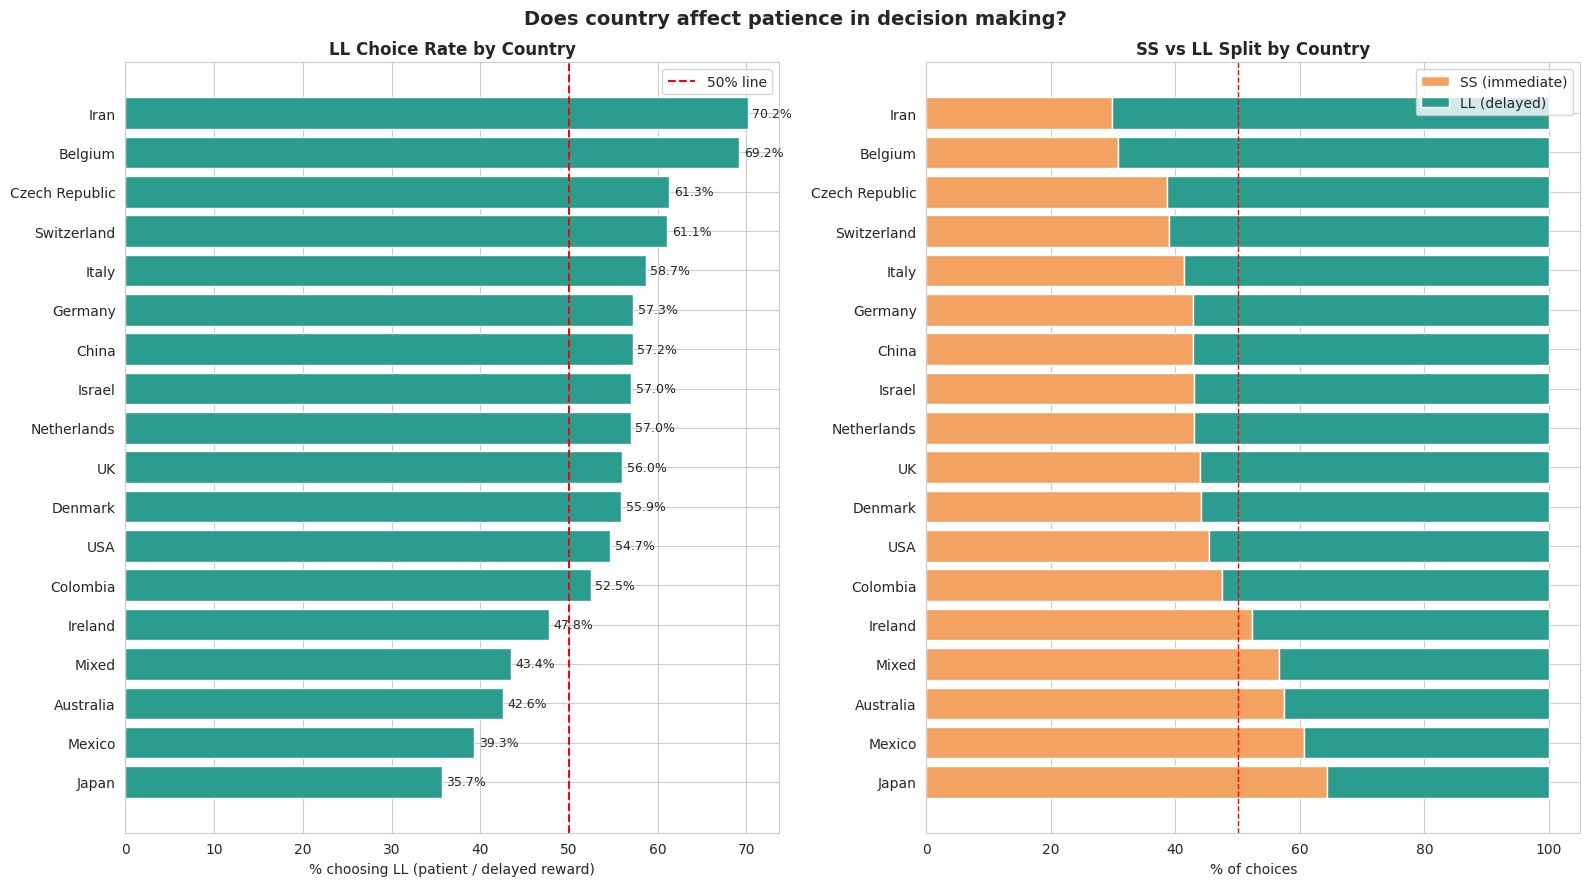

In [ ]:
# ── 1. PREPARE ────────────────────────────────────────────────────────────────
country_choice = (df_clean.groupby('country')['choice']
                  .agg(['mean', 'count'])
                  .reset_index()
                  .rename(columns={'mean': 'll_rate', 'count': 'n_trials'})
                  .query("n_trials > 500")          # only countries with enough data
                  .sort_values('ll_rate', ascending=True))

country_choice['ss_rate'] = 1 - country_choice['ll_rate']

print(f"Countries included: {len(country_choice)}")
print(country_choice[['country', 'll_rate', 'n_trials']].to_string(index=False))

# ── 2. PLOT ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(country_choice) * 0.5)))

# Plot 1 — LL rate per country (horizontal bar)
bars = axes[0].barh(
    country_choice['country'],
    country_choice['ll_rate'] * 100,
    color='#2A9D8F', edgecolor='white'
)
axes[0].axvline(50, color='red', linestyle='--', linewidth=1.5, label='50% line')
axes[0].set_xlabel("% choosing LL (patient / delayed reward)")
axes[0].set_title("LL Choice Rate by Country", fontweight='bold')
axes[0].legend()

# Add % labels on bars
for bar, val in zip(bars, country_choice['ll_rate'] * 100):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va='center', fontsize=9)

# Plot 2 — Stacked bar SS vs LL per country
axes[1].barh(country_choice['country'],
             country_choice['ss_rate'] * 100,
             color='#F4A261', label='SS (immediate)', edgecolor='white')
axes[1].barh(country_choice['country'],
             country_choice['ll_rate'] * 100,
             left=country_choice['ss_rate'] * 100,
             color='#2A9D8F', label='LL (delayed)', edgecolor='white')
axes[1].axvline(50, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel("% of choices")
axes[1].set_title("SS vs LL Split by Country", fontweight='bold')
axes[1].legend()

plt.suptitle("Does country affect patience in decision making?",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_country_vs_choice.png", bbox_inches='tight')
plt.show()

We see meaningful country‑level differences in LL choice rates after filtering small samples, but we treat country as a coarse context variable not a causal culture effect — because many experimental factors differ across countries.

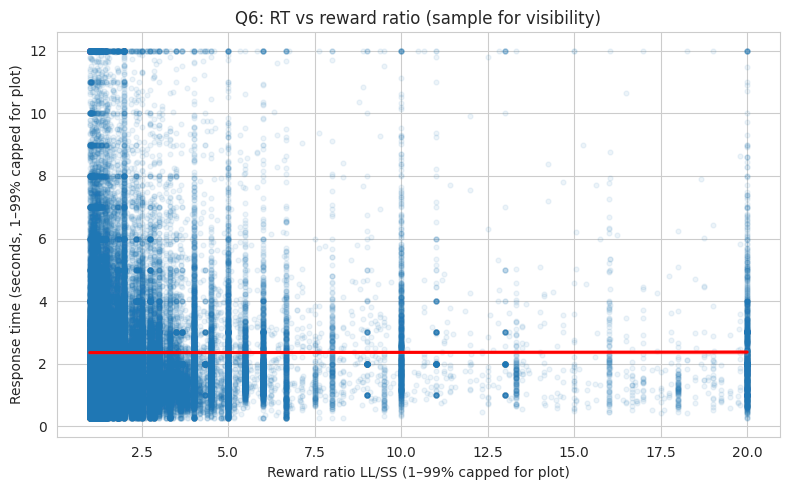

Pearson correlation (ratio vs RT), capped sample: 0.001
If correlation is negative → higher ratio tends to go with slightly faster RT on this view.
If positive → higher ratio tends to go with slower RT.
Plot sample size: 80,000 | Full rows used for prep: 1,020,113


In [ ]:
sns.set_style('whitegrid')

# Build analysis frame
q6 = df_clean[df_clean['choice'].isin([0, 1]) & df_clean['rt'].notna() & (df_clean['rt'] > 0)].copy()
q6 = q6[q6['ss_value'] > 0].copy()
q6['reward_ratio'] = q6['ll_value'] / q6['ss_value']
q6 = q6[np.isfinite(q6['reward_ratio'])]

# Cap ratio for plot (same idea as Q3 — extreme values stretch the x-axis)
r_low, r_high = q6['reward_ratio'].quantile([0.01, 0.99])
q6['ratio_plot'] = q6['reward_ratio'].clip(r_low, r_high)

# Cap RT for plot (optional — keeps focus on typical response times)
rt_low, rt_high = q6['rt'].quantile([0.01, 0.99])
q6['rt_plot'] = q6['rt'].clip(rt_low, rt_high)

# Random sample for plotting speed
SAMPLE_N = 80_000
if len(q6) > SAMPLE_N:
    plot_df = q6.sample(n=SAMPLE_N, random_state=42)
else:
    plot_df = q6

plt.figure(figsize=(8, 5))
sns.regplot(
    data=plot_df,
    x='ratio_plot',
    y='rt_plot',
    scatter_kws={'alpha': 0.08, 's': 12},
    line_kws={'color': 'red'},
)
plt.xlabel('Reward ratio LL/SS (1–99% capped for plot)')
plt.ylabel('Response time (seconds, 1–99% capped for plot)')
plt.title('Q6: RT vs reward ratio (sample for visibility)')
plt.tight_layout()
plt.show()

# Simple correlation on capped values (easy to report)
corr = plot_df['ratio_plot'].corr(plot_df['rt_plot'])
print(f"Pearson correlation (ratio vs RT), capped sample: {corr:.3f}")
print("If correlation is negative → higher ratio tends to go with slightly faster RT on this view.")
print("If positive → higher ratio tends to go with slower RT.")
print(f"Plot sample size: {len(plot_df):,} | Full rows used for prep: {len(q6):,}")

We see no relationship here between response time and reward ratio

/tmp/ipykernel_47846/1038436026.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_47846/1038436026.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


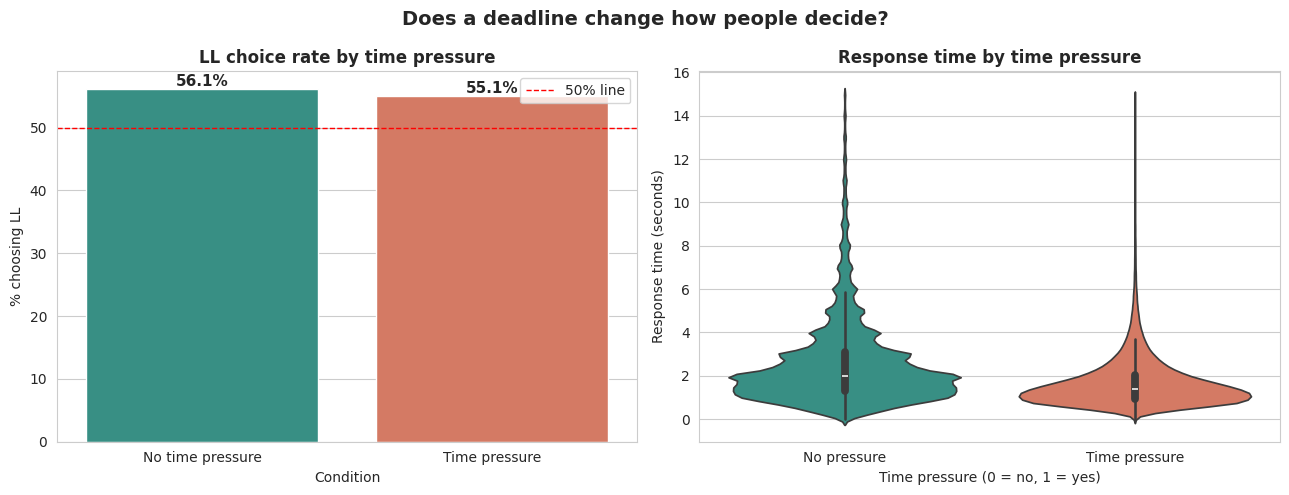

In [ ]:
# Time pressure vs LL rate + RT (needs: time_pressure, choice, rt on df_clean)
time_pressure_choice = df_clean.groupby("time_pressure")["choice"].mean().reset_index()
time_pressure_choice["time_pressure_label"] = time_pressure_choice["time_pressure"].map(
    {0: "No time pressure", 1: "Time pressure"}
)
time_pressure_choice["ll_rate_pct"] = time_pressure_choice["choice"] * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(
    data=time_pressure_choice,
    x="time_pressure_label",
    y="ll_rate_pct",
    palette=["#2A9D8F", "#E76F51"],
    ax=axes[0],
    legend=False,
)
axes[0].axhline(50, color="red", linestyle="--", linewidth=1, label="50% line")
axes[0].set_title("LL choice rate by time pressure", fontweight="bold")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("% choosing LL")
axes[0].legend()
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
        ha="center",
        fontsize=11,
        fontweight="bold",
    )
sns.violinplot(
    data=df_clean[df_clean["rt"] <= 15],
    x="time_pressure",
    y="rt",
    palette=["#2A9D8F", "#E76F51"],
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Response time by time pressure", fontweight="bold")
axes[1].set_xlabel("Time pressure (0 = no, 1 = yes)")
axes[1].set_ylabel("Response time (seconds)")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No pressure", "Time pressure"])
plt.suptitle("Does a deadline change how people decide?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


The hypothesis was that time pressure affect behavior, though in that case here is not that significant still we see some relationship.

/tmp/ipykernel_47846/38921523.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='presentation_of_information', y='choice', data=df_clean, palette='viridis')


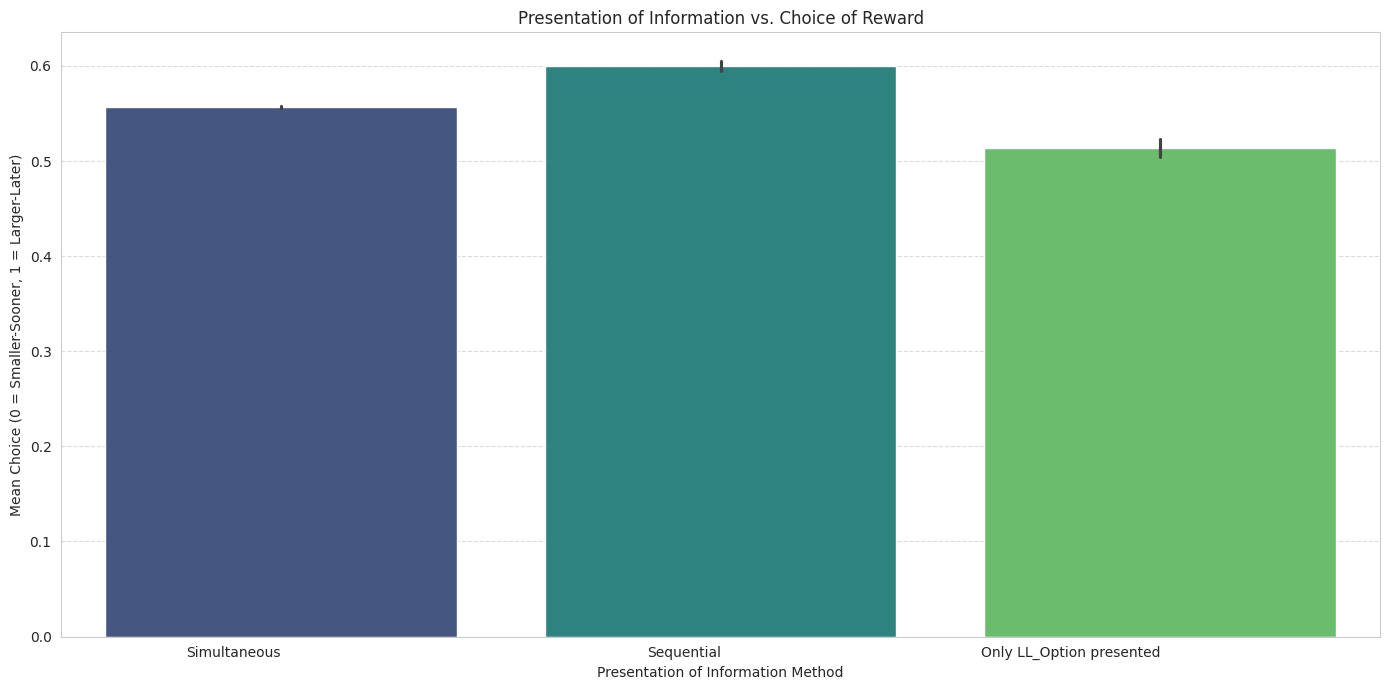

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='presentation_of_information', y='choice', data=df_clean, palette='viridis')
plt.title('Presentation of Information vs. Choice of Reward')
plt.xlabel('Presentation of Information Method')
plt.ylabel('Mean Choice (0 = Smaller-Sooner, 1 = Larger-Later)')
plt.xticks(rotation=0, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This visualization (the bar plot of 'Proportion of Larger-Later Choices by Presentation of Information') helps us understand if how information is presented influences people's decisions to choose a larger reward that comes later, versus a smaller, sooner reward.

Each bar represents a different method of 'presentation_of_information' (e.g., how the choices were displayed to the participants). The height of each bar on the y-axis indicates the average 'choice' value for that presentation method. Since 'choice' is 1 for Larger-Later and 0 for Smaller-Sooner, the bar height effectively shows the proportion of participants who chose the Larger-Later option under that specific presentation method.

/tmp/ipykernel_47846/1317702044.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='choice', data=df_clean, order=age_labels, palette='viridis')


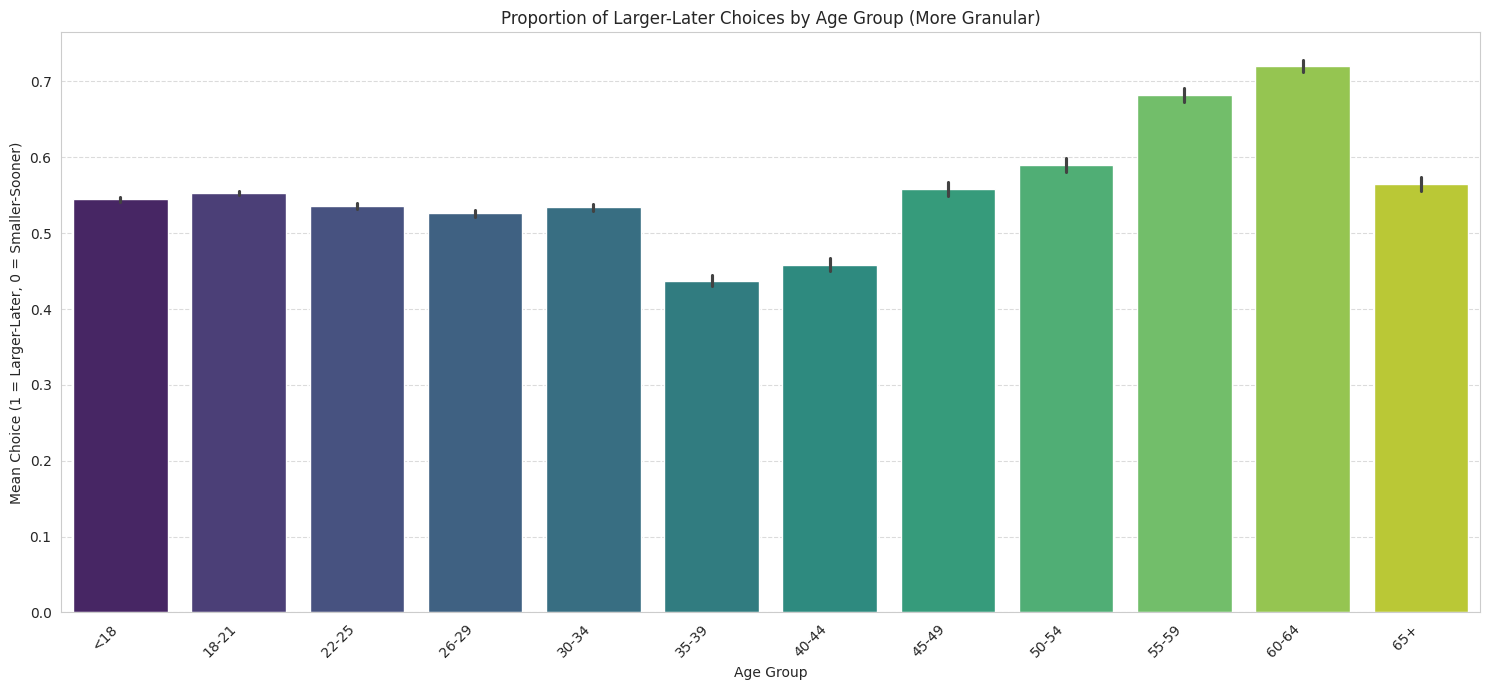

In [ ]:
# Define new, less broad age groups and labels
age_bins = [0, 18, 22, 26, 30, 35, 40, 45, 50, 55, 60, 65, np.inf]
age_labels = ['<18', '18-21', '22-25', '26-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65+']

# Create 'age_group' column in df_clean using the new bins
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(15, 7))
sns.barplot(x='age_group', y='choice', data=df_clean, order=age_labels, palette='viridis')
plt.title('Proportion of Larger-Later Choices by Age Group (More Granular)')
plt.xlabel('Age Group')
plt.ylabel('Mean Choice (1 = Larger-Later, 0 = Smaller-Sooner)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

If a bar is tall, it means that age group tends to choose the Larger-Later option more often. If a bar is short, it means that age group tends to choose the Smaller-Sooner option more often, I chose to shorten the age groups in order to avoid a misleading visualization hiding too much real distribution.

MI computed on a random sample of n=200,000 trials (total usable rows: 1,026,276).


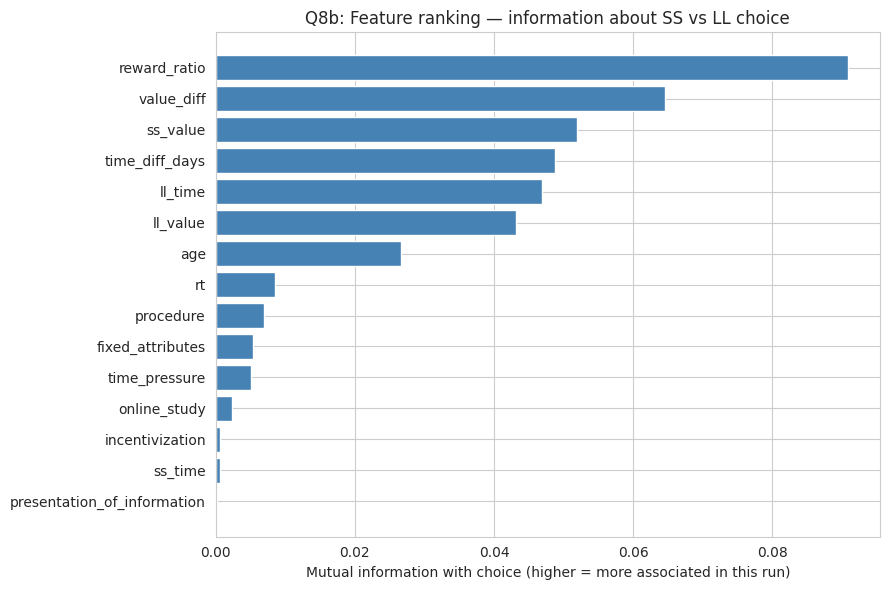

,feature,mutual_info
0,reward_ratio,0.0909
1,value_diff,0.0645
2,ss_value,0.0519
3,time_diff_days,0.0488
4,ll_time,0.0470
5,ll_value,0.0432
6,age,0.0267
7,rt,0.0085
8,procedure,0.0069
9,fixed_attributes,0.0054


Reminder: MI measures association (including non-linear), not causation or direction. High MI for amounts/delays/ratios partly reflects how the choice task is built; use context variables (procedure, incentives, online, etc.) when discussing study design.


In [ ]:
# Which variables carry most information about choice? (Mutual Information)
# Validity: MI ranks association, not causation. Option-size/delay features often rank high because
# the choice is defined by those quantities on each trial (task structure), not only individual traits.



mi_df = df_clean[df_clean['choice'].isin([0, 1])].copy()
y = mi_df['choice'].astype(int).values

mi_df['reward_ratio'] = np.where(
    mi_df['ss_value'] > 0,
    mi_df['ll_value'] / mi_df['ss_value'],
    np.nan,
)

# Numeric features (trial-level)
num_features = [
    'ss_value', 'ss_time', 'll_value', 'll_time',
    'rt', 'value_diff', 'time_diff_days', 'reward_ratio',
    'age', 'time_pressure', 'online_study',
]

# Context categoricals (already in clean df)
cat_features = [
    'procedure', 'incentivization', 'presentation_of_information', 'fixed_attributes',
]

feature_names = []
X_parts = []
discrete_flags = []

for col in num_features:
    if col not in mi_df.columns:
        continue
    v = pd.to_numeric(mi_df[col], errors='coerce')
    v = v.fillna(v.median() if v.median() is not np.nan else 0) # Handle case where median might be nan
    X_parts.append(v.values.reshape(-1, 1))
    feature_names.append(col)
    discrete_flags.append(False)

for col in cat_features:
    if col not in mi_df.columns:
        continue
    le = LabelEncoder()
    v = le.fit_transform(mi_df[col].astype(str).fillna('missing'))
    X_parts.append(v.reshape(-1, 1))
    feature_names.append(col)
    discrete_flags.append(True)

X = np.hstack(X_parts)
discrete = np.array(discrete_flags, dtype=bool)

# Sample for speed (fixed seed for reproducibility)
SAMPLE_N = 200_000
if len(y) > SAMPLE_N:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(y), size=SAMPLE_N, replace=False)
    Xs, ys = X[idx], y[idx]
    print(f'MI computed on a random sample of n={SAMPLE_N:,} trials (total usable rows: {len(y):,}).')
else:
    Xs, ys = X, y
    print(f'MI computed on all n={len(y):,} usable trials.')

mi = mutual_info_classif(Xs, ys, discrete_features=discrete, random_state=42)

ranking = (
    pd.DataFrame({'feature': feature_names, 'mutual_info': mi})
    .sort_values('mutual_info', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 6))
plt.barh(ranking['feature'][::-1], ranking['mutual_info'][::-1], color='steelblue')
plt.xlabel('Mutual information with choice (higher = more associated in this run)')
plt.title('Q8b: Feature ranking — information about SS vs LL choice')
plt.tight_layout()
plt.show()

display(ranking.round(4))

print(
    'Reminder: MI measures association (including non-linear), not causation or direction. '
    'High MI for amounts/delays/ratios partly reflects how the choice task is built; '
    'use context variables (procedure, incentives, online, etc.) when discussing study design.'
    )


We ranked variables by mutual information (MI) with the binary choice (SS vs LL). MI captures any statistical association with choice, including relationships that are not simple straight-line correlations.

Features higher on the list carry more information about whether the trial ended in SS (0) or LL (1) in this dataset and preprocessing setup. The exact numbers can change slightly if you change filters, sample size, or random seed (we often subsample very large files for speed).


Reward size and timing (e.g. amounts, delays, differences, and reward ratio (LL/SS)) often rank high because every trial varies those quantities and they define the decision problem. That does not by itself prove people “only care about money” or that those factors cause choices in a causal sense—it means they co-occur strongly with which option was chosen in the data.

Columns like procedure, incentivization, online vs lab, or time pressure can still matter for interpretation and for fair comparisons across studies, even when MI is smaller than trial-level payoff variables.

Mutual information measures association, not causation; high MI is not proof that changing that variable in an experiment would change behavior in the same way.

/tmp/ipykernel_47846/2615611726.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='rt', data=df_filtered_rt, order=age_labels, palette='viridis')


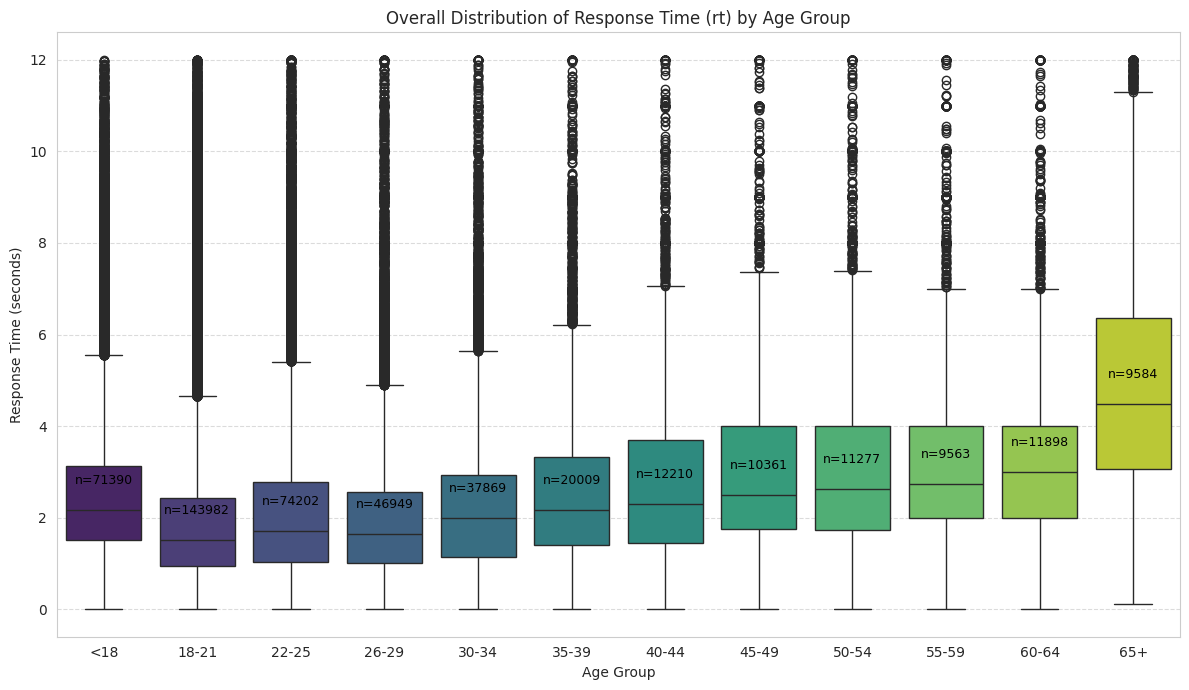

In [ ]:
# Calculate the 99th percentile of response times (rt) to identify a cutoff for outliers
rt_high = df_clean['rt'].quantile(0.99)
# Filter the DataFrame to include only response times less than or equal to the 99th percentile
# This effectively removes the top 1% of the slowest response times for better visualization
df_filtered_rt = df_clean[df_clean['rt'] <= rt_high].copy()

plt.figure(figsize=(12, 7))
# Create a box plot to visualize the distribution of response times across different age groups
# The 'age_group' column is on the x-axis, 'rt' (response time) on the y-axis
sns.boxplot(x='age_group', y='rt', data=df_filtered_rt, order=age_labels, palette='viridis')
plt.title('Overall Distribution of Response Time (rt) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Response Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Calculate the count of observations for each age group
age_group_counts = df_filtered_rt['age_group'].value_counts().reindex(age_labels)

# Add text annotations for the count of observations above each box plot
for i, age_group in enumerate(age_labels):
    count = age_group_counts.get(age_group, 0)
    if count > 0:
        # Get the median value for placing the annotation near the box
        median_rt = df_filtered_rt[df_filtered_rt['age_group'] == age_group]['rt'].median()
        # Adjust y-coordinate for annotation placement to be above the box, or at a reasonable height if median is low
        plt.text(i, median_rt + 0.5, f'n={count}', ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()

As people get older, they generally take longer to respond — and the spread of response times gets wider too. Younger participants tend to answer quickly and consistently, while older adults show both slower responses and more variability. In other words:

Speed slows with age

Consistency decreases with age

Older groups include both fast and very slow responders

In [ ]:
# Define new, less broad age groups and labels (if not already defined or to ensure consistency)
age_bins = [0, 18, 22, 26, 30, 35, 40, 45, 50, 55, 60, 65, np.inf]
age_labels = ['<18', '18-21', '22-25', '26-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65+']

# Create 'age_group' column in df_clean using the new bins
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels, right=False)

# Calculate the count of observations for each age group in the full df_clean
age_group_full_counts = df_clean['age_group'].value_counts().reindex(age_labels, fill_value=0)

# Calculate the percentage for each age group
age_group_percentages = (age_group_full_counts / age_group_full_counts.sum()) * 100

# Display the results
print("Percentage of each age group in the full dataset:")
display(age_group_percentages.round(2).to_frame(name='Percentage'))

Percentage of each age group in the full dataset:


,Percentage
age_group,
<18,15.43
18-21,31.14
22-25,16.09
26-29,10.18
30-34,8.21
35-39,4.37
40-44,2.68
45-49,2.31
50-54,2.50


Here is a tab showing the distribution of population by age


--- Weights for procedure ---


,n_trials,pct_of_all_rows,LL_rate_pct
procedure,,,
Full Cross,466394,45.45,59.28
Fixed Choice Set,158693,15.46,55.95
Other,125913,12.27,53.91
Kirby Questionnaire,94726,9.23,41.47
Titration Procedure,88368,8.61,59.79
Random Choice,68457,6.67,46.63
Staircase Procedure,17207,1.68,69.73
5-Trial Delay Discounting Task,6518,0.64,56.84



--- Weights for incentivization ---


,n_trials,pct_of_all_rows,LL_rate_pct
incentivization,,,
Hypothetical,594798,57.96,54.32
Potentially Real,421197,41.04,58.00
Real,10281,1.00,53.72



--- Weights for online_study ---


,n_trials,pct_of_all_rows,LL_rate_pct
online_study,,,
0,842353,82.08,57.13
1,183923,17.92,49.86


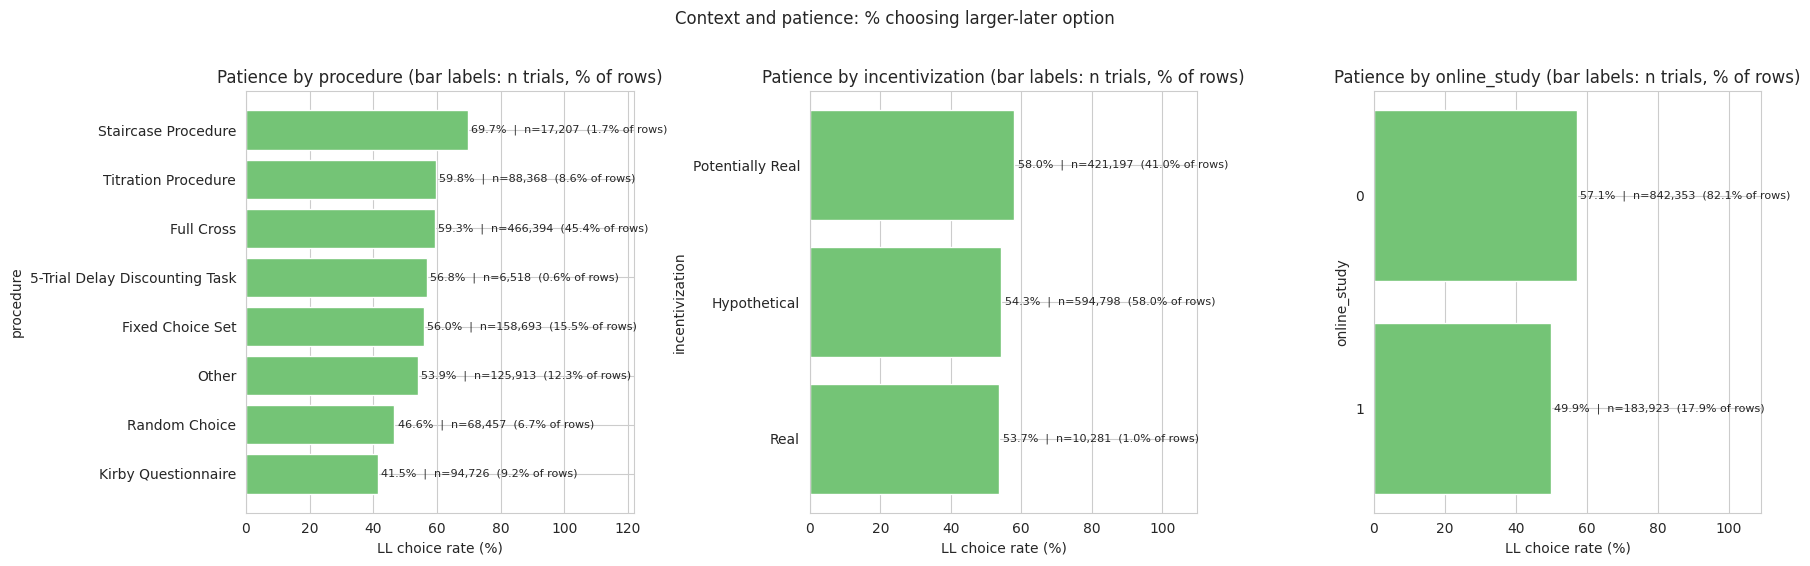

In [ ]:
sns.set_style('whitegrid')
if 'df_clean' not in globals():
    print('Run the cleaning code cell first so `df_clean` exists.')
else:
    plot_cols = [c for c in ['procedure', 'incentivization', 'online_study'] if c in df_clean.columns]
    if not plot_cols:
        print('No context columns found on df_clean.')
    else:
        n = len(plot_cols)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 5.5), squeeze=False)
        for idx, col in enumerate(plot_cols):
            ax = axes[0, idx]
            grp = df_clean.groupby(col, observed=False)
            counts = grp.size()
            summary = grp['choice'].mean().mul(100).sort_values(ascending=True)
            counts = counts.reindex(summary.index)
            y_pos = range(len(summary))
            ax.barh(y_pos, summary.values, color='#74c476', edgecolor='white')
            ax.set_yticks(list(y_pos))
            ax.set_yticklabels(list(summary.index))
            ax.set_xlabel('LL choice rate (%)')
            ax.set_ylabel(col)
            ax.set_title(f'Patience by {col} (bar labels: n trials, % of rows)')
            rmax = float(summary.values.max())
            xmax = max(rmax + 52, 60)
            ax.set_xlim(0, xmax)
            for i, (label, rate) in enumerate(summary.items()):
                ntri = int(counts.loc[label])
                pct_all = 100 * ntri / len(df_clean)
                ax.text(
                    rate + 1.0,
                    i,
                    f'{rate:.1f}%  |  n={ntri:,}  ({pct_all:.1f}% of rows)',
                    va='center',
                    ha='left',
                    fontsize=8,
                    clip_on=False,
                )
            print(f'\n--- Weights for {col} ---')
            display(
                pd.DataFrame({
                    'n_trials': counts,
                    'pct_of_all_rows': (100 * counts / len(df_clean)).round(2),
                    'LL_rate_pct': summary.round(2),
                }).sort_values('n_trials', ascending=False)
            )
        plt.suptitle('Context and patience: % choosing larger-later option', y=1.02, fontsize=12)
        plt.tight_layout()
        plt.show()

The number changed a lot depending on how the choice was asked.

Conclusion (context vs “now vs later” choices)

We measured how often people chose the larger, later option (LL rate). Task type (procedure) mattered most: across categories, LL rates ranged from about 41% to 70%, a spread of roughly 30 percentage points, showing that how the trade-off is presented strongly affects observed patience. Online vs in-lab (online_study) showed a smaller but clear gap (~8 percentage points in our chart), suggesting digital settings can look more “take it now” on average—interpret cautiously (attention, sampling, design—not proof of permanent traits). Incentive framing (incentivization) produced only a small spread (~4 percentage points), so reward realism appears less influential than task design in this dataset.

Practical takeaway: For subscription/tier decisions, experiment format and channel context must be controlled or disclosed before claiming segment differences in patience.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')